<a href="https://www.kaggle.com/code/nivedisdufare/eda-titanic?scriptVersionId=346716299" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/nivedisdufare/titanic-dataset/Titanic-Dataset.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Importing the dataset
df = pd.read_csv('/kaggle/input/datasets/nivedisdufare/titanic-dataset/Titanic-Dataset.csv')

In [4]:
# Shape
df.shape

(891, 12)

In [5]:
# Previewing the data
df.head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# Listing down the columns
df.columns.values

array(['PassengerId', 'Survived', 'Pclass', 'Name', 'Gender', 'Age',
       'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype=object)


 **Categorical Columns**
* Survived
* PClass
* Gender
* SibSp
* Parch
* Embarked 

**Numerical Columns**
* Age
* Fare
* PassengerId

**Mixed Columns**
* Name
* Ticket
* Cabin

In [7]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Gender       891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Gender           0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Few conclusions

1. Missing values in Age, Cabin and Embarked columns
2. More than 70 percent values are missing in cabin columns, will have to drop
3. Few columns have inappropriate data types

In [9]:

# Dropping cabin column

df.drop(columns=['Cabin'],inplace=True)

In [10]:
# Imputing missing values for age
# Strategy - mean

df['Age'] = df['Age'].fillna(df['Age'].mean())

In [11]:
# Imputing missing values for embarked

# finding the most appeared value in embarked column

df['Embarked'].value_counts()

# S it is

df['Embarked'] = df['Embarked'].fillna('S')

In [12]:
# Want to check one more thing...

# Should I change the SibSp and Parch to categories

df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

In [13]:

df['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64


# **Changing data type for the following cols**
* Survived(category)
* PClass(category)
* Gender(category)
* Age(int)
* Embarked(category)

In [14]:
df['Survived']=df['Survived'].astype('category')
df['Pclass']=df['Pclass'].astype('category')
df['Gender']=df['Gender'].astype('category')
df['Age']=df['Age'].astype('int')
df['Embarked']=df['Embarked'].astype('category')

In [15]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Gender       891 non-null    category
 5   Age          891 non-null    int64   
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Embarked     891 non-null    category
dtypes: category(4), float64(1), int64(4), object(2)
memory usage: 52.8+ KB


In [16]:

# Five point summary
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,29.544332,0.523008,0.381594,32.204208
std,257.353842,13.013778,1.102743,0.806057,49.693429
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,29.000000,0.000000,0.000000,14.454200
75%,668.500000,35.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


Out of 891 62% people died in the accident


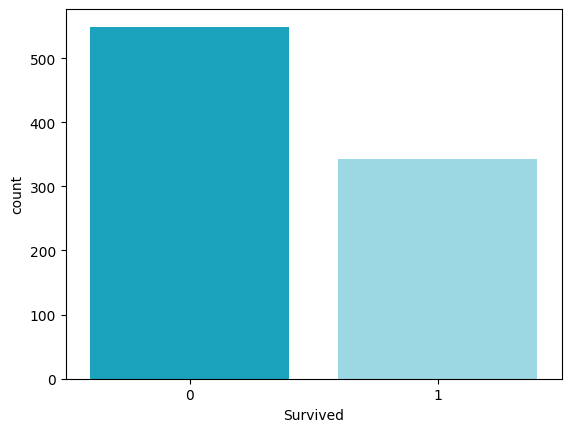

In [17]:
# Univariate Analysis
# Let's start with the Survived col
sns.countplot(x='Survived', data=df, hue='Survived', palette={0: '#00B4D8', 1: '#90E0EF'}, legend=False)
death_percent = round((df['Survived'].value_counts().values[0] / 891) * 100)
print("Out of 891 {}% people died in the accident".format(death_percent))

Pclass
3    55.106622
1    24.242424
2    20.650954
Name: count, dtype: float64


<Axes: xlabel='Pclass', ylabel='count'>

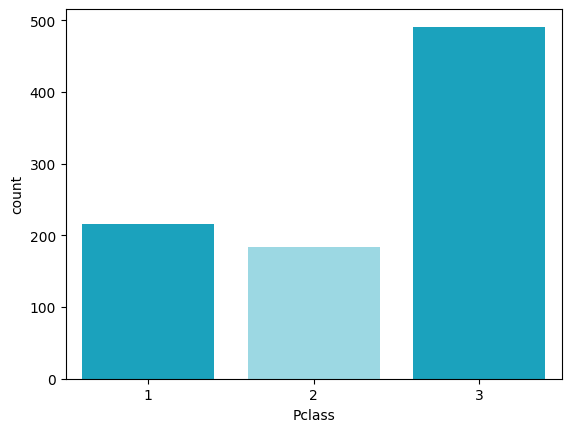

In [18]:
print((df['Pclass'].value_counts() / 891) * 100)
sns.countplot(data=df, x='Pclass', hue='Pclass', 
              palette={1: '#00B4D8', 2: '#90E0EF', 3: '#00B4D8'}, 
              legend=False)
# Conclusion : Pclass 3 was the most crowded class

Gender
male      64.758698
female    35.241302
Name: count, dtype: float64


<Axes: xlabel='Gender', ylabel='count'>

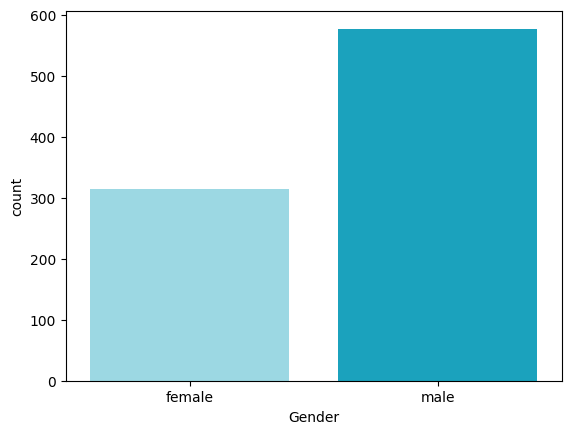

In [19]:
print((df['Gender'].value_counts() / 891) * 100)
sns.countplot(data=df, x='Gender', hue='Gender', 
              palette={'male': '#00B4D8', 'female': '#90E0EF'}, 
              legend=False)

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64


<Axes: xlabel='SibSp', ylabel='count'>

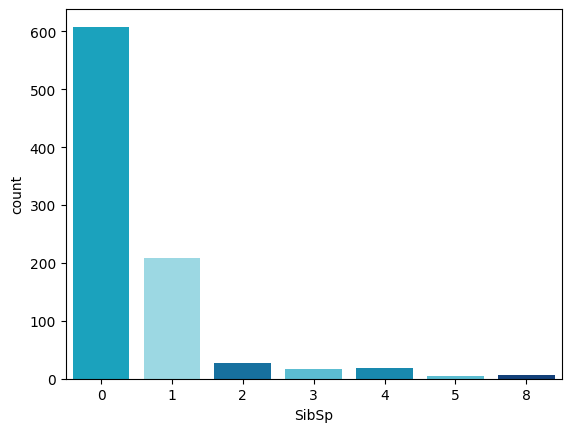

In [20]:
print(df['SibSp'].value_counts())
sns.countplot(data=df, x='SibSp', hue='SibSp', palette=['#00B4D8', '#90E0EF', '#0077B6', '#48CAE4', '#0096C7', '#48CAE4', '#023E8A'], legend=False)

Parch
0    76.094276
1    13.243547
2     8.978676
5     0.561167
3     0.561167
4     0.448934
6     0.112233
Name: count, dtype: float64


<Axes: xlabel='Parch', ylabel='count'>

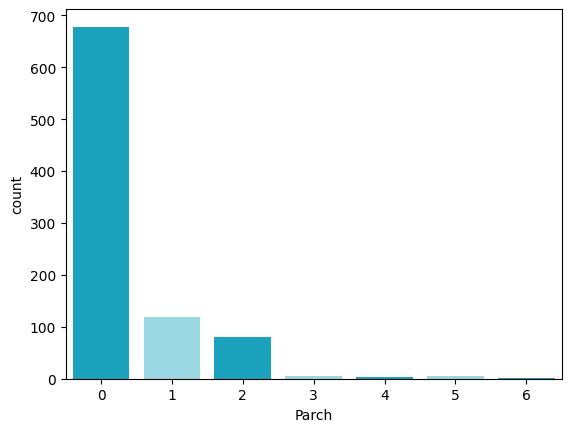

In [21]:
print((df['Parch'].value_counts() / 891) * 100)
sns.countplot(data=df, x='Parch', hue='Parch',
              palette={0: '#00B4D8', 1: '#90E0EF', 2: '#00B4D8', 3: '#90E0EF', 4: '#00B4D8', 5: '#90E0EF', 6: '#00B4D8'},
              legend=False)

Embarked
S    72.502806
C    18.855219
Q     8.641975
Name: count, dtype: float64


<Axes: xlabel='Embarked', ylabel='count'>

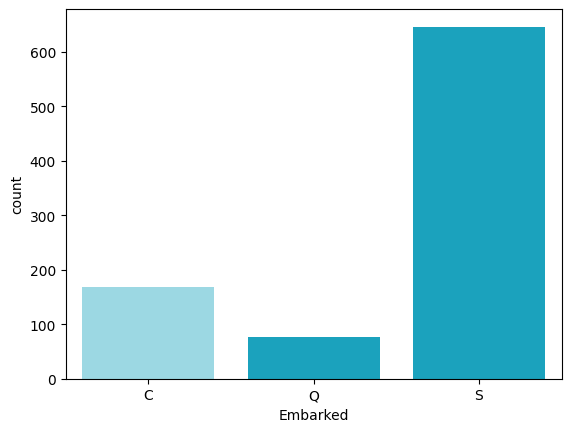

In [22]:
print((df['Embarked'].value_counts() / 891) * 100)
sns.countplot(data=df, x='Embarked', hue='Embarked',
              palette={'S': '#00B4D8', 'C': '#90E0EF', 'Q': '#00B4D8'},
              legend=False)

0.45956263424701577
0.9865867453652877


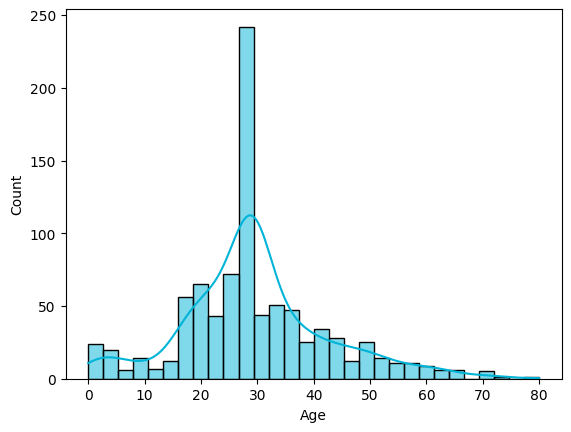

In [23]:
# Age column
sns.histplot(df['Age'], color='#00B4D8', kde=True, 
             line_kws={'color': '#90E0EF'})

print(df['Age'].skew())
print(df['Age'].kurt())

<Axes: xlabel='Age'>

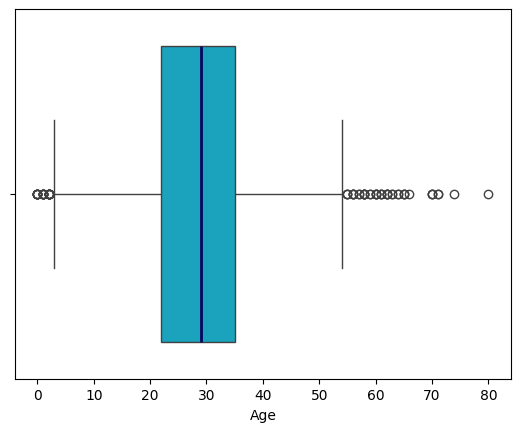

In [24]:
sns.boxplot(x=df['Age'], color='#00B4D8', 
            medianprops=dict(color='#03045E', linewidth=2))

In [25]:
# Just out of curiosity
print("People with age in between 60 and 70 are", df[(df['Age'] > 60) & (df['Age'] < 70)].shape[0])
print("People with age greater than 70 and 75 are", df[(df['Age'] >= 70) & (df['Age'] <= 75)].shape[0])
print("People with age greater than 75 are", df[df['Age'] > 75].shape[0])

print('-' * 50)

print("People with age between 0 and 1", df[df['Age'] < 1].shape[0])

People with age in between 60 and 70 are 15
People with age greater than 70 and 75 are 6
People with age greater than 75 are 1
--------------------------------------------------
People with age between 0 and 1 7


<Axes: xlabel='Fare', ylabel='Count'>

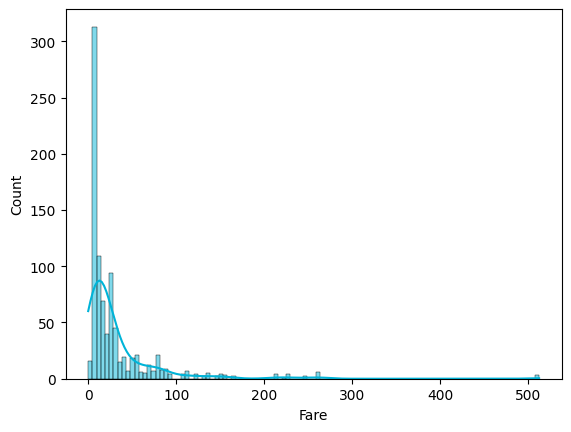

In [26]:
# Fare column
sns.histplot(df['Fare'], color='#00B4D8', kde=True,
             line_kws={'color': '#03045E'})

In [27]:
print(df['Fare'].skew())
print(df['Fare'].kurt())

4.787316519674893
33.39814088089868


<Axes: xlabel='Fare'>

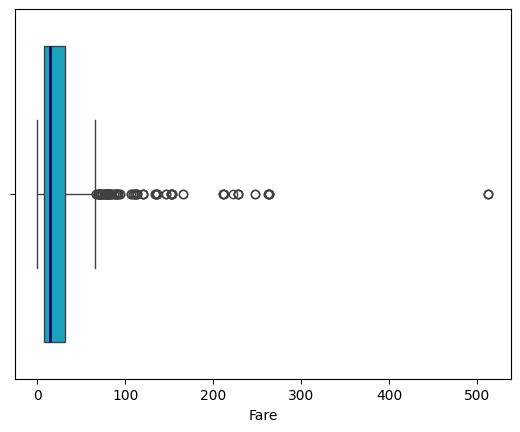

In [28]:
sns.boxplot(x=df['Fare'], color='#00B4D8', 
            medianprops=dict(color='#03045E', linewidth=2))

* Highly skewed data, a lot of people had cheaper tickets
* Outliers are there in the data

In [29]:

print("People with fare in between $200 and $300",df[(df['Fare']>200) & (df['Fare']<300)].shape[0])
print("People with fare in greater than $300",df[df['Fare']>300].shape[0])

People with fare in between $200 and $300 17
People with fare in greater than $300 3


Survived,0,1
Pclass,,
1,37.0,63.0
2,52.7,47.3
3,75.8,24.2


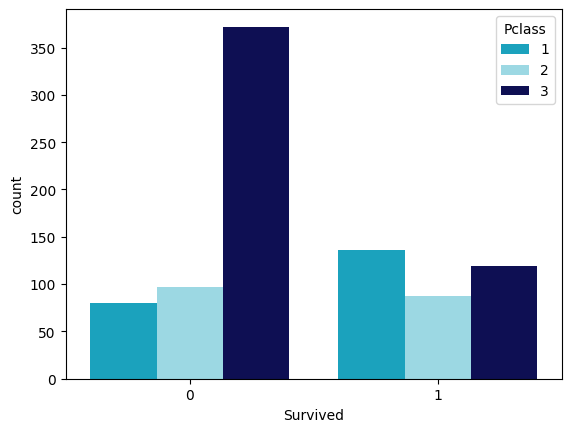

In [30]:
# Multivariate Analysis

# Survival with Pclass
sns.countplot(data=df, x='Survived', hue='Pclass',
              palette={1: '#00B4D8', 2: '#90E0EF', 3: '#03045E'},
              legend=True)

pd.crosstab(df['Pclass'], df['Survived']).apply(lambda r: round((r / r.sum()) * 100, 1), axis=1)

Survived,0,1
Gender,,
female,25.8,74.2
male,81.1,18.9


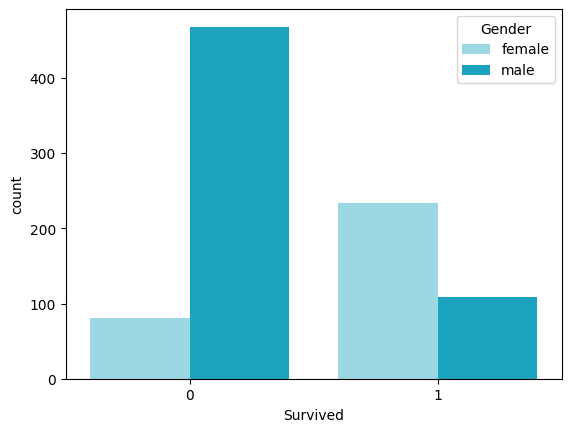

In [31]:
# Survival with Gender
sns.countplot(data=df, x='Survived', hue='Gender',
              palette={'male': '#00B4D8', 'female': '#90E0EF'},
              legend=True)

pd.crosstab(df['Gender'], df['Survived']).apply(lambda r: round((r / r.sum()) * 100, 1), axis=1)


Survived,0,1
Embarked,,
C,44.6,55.4
Q,61.0,39.0
S,66.1,33.9


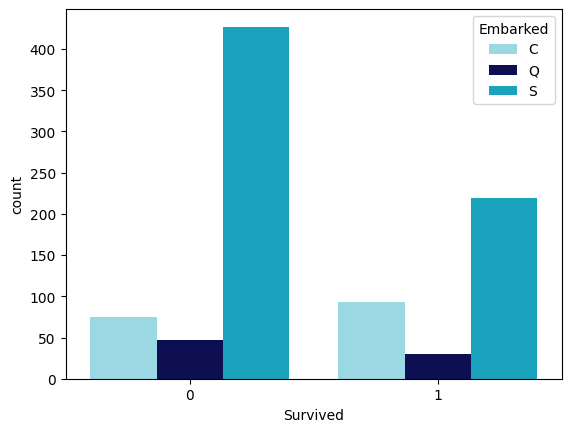

In [32]:
# Survival with Embarked
sns.countplot(data=df, x='Survived', hue='Embarked',
              palette={'S': '#00B4D8', 'C': '#90E0EF', 'Q': '#03045E'},
              legend=True)

pd.crosstab(df['Embarked'], df['Survived']).apply(lambda r: round((r / r.sum()) * 100, 1), axis=1)

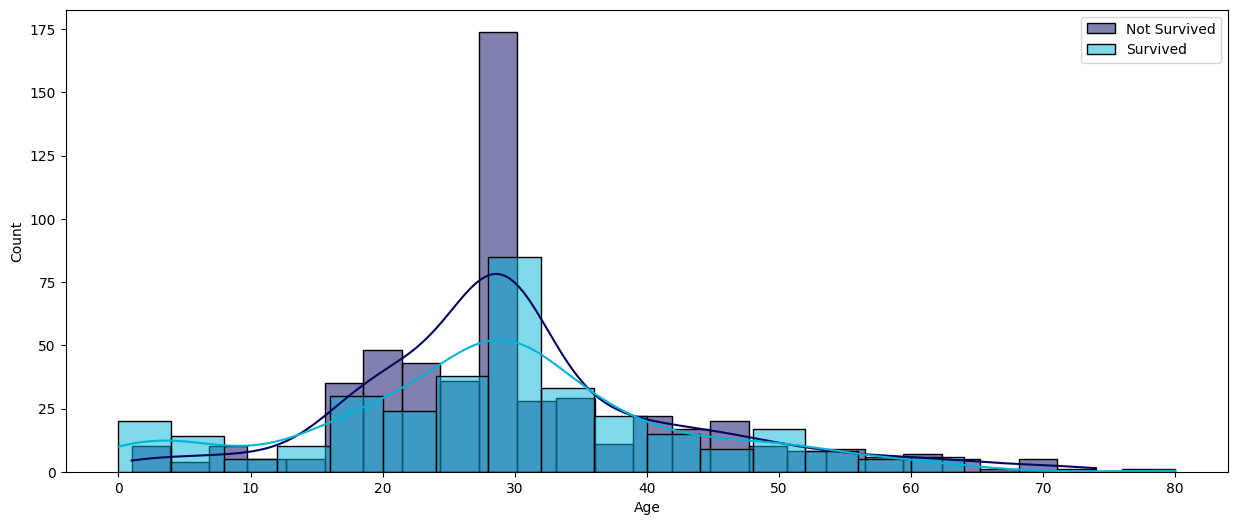

In [33]:
# Survived with Age
plt.figure(figsize=(15, 6))
sns.histplot(df[df['Survived'] == 0]['Age'], color='#03045E', kde=True, 
             line_kws={'color': '#03045E'}, label='Not Survived')
sns.histplot(df[df['Survived'] == 1]['Age'], color='#00B4D8', kde=True, 
             line_kws={'color': '#03045E'}, label='Survived')
plt.legend()

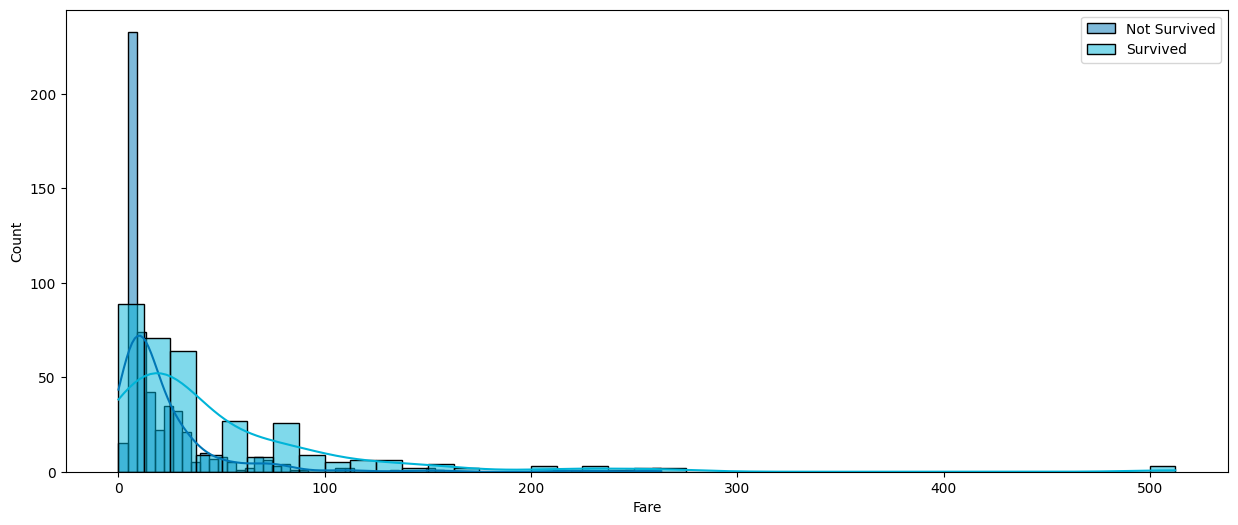

In [34]:
# Survived with Fare
plt.figure(figsize=(15, 6))
sns.histplot(df[df['Survived'] == 0]['Fare'], color='#0077B6', kde=True, 
             line_kws={'color': '#03045E'}, label='Not Survived')
sns.histplot(df[df['Survived'] == 1]['Fare'], color='#00B4D8', kde=True, 
             line_kws={'color': '#03045E'}, label='Survived')
plt.legend()

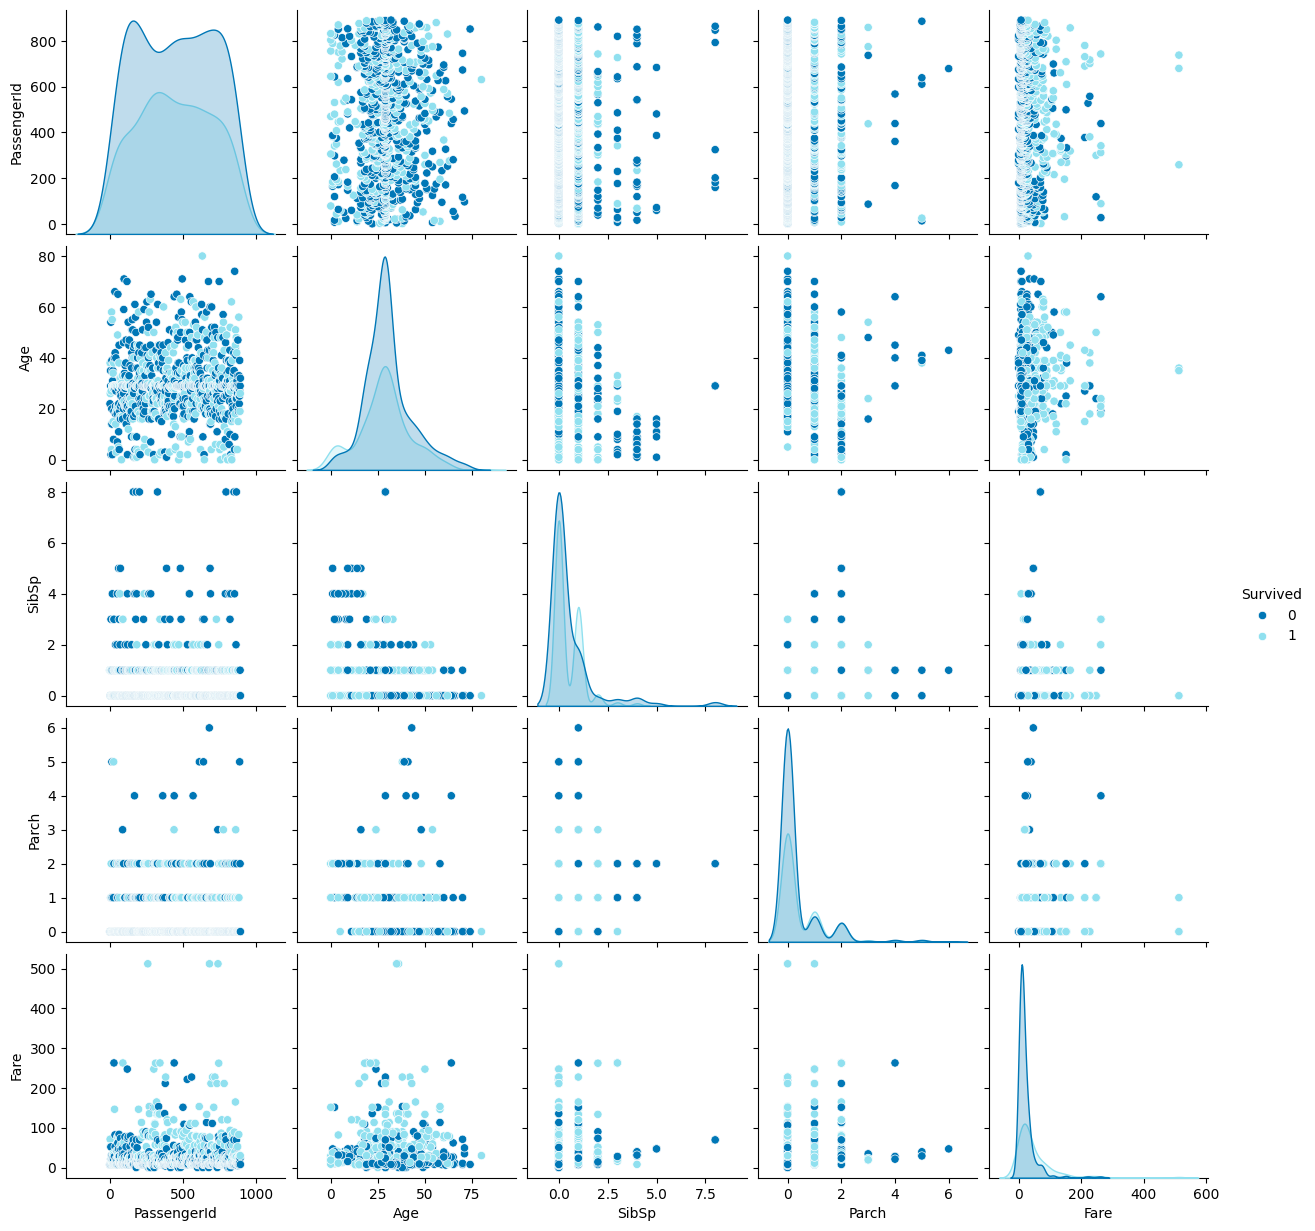

In [35]:

sns.pairplot(df, hue='Survived', 
             palette={0: '#0077B6', 1: '#90E0EF'})

<Axes: >

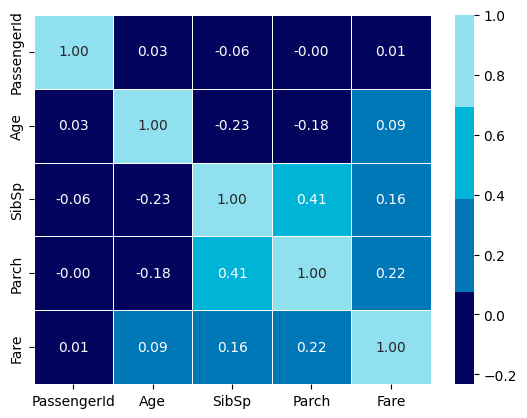

In [36]:
sns.heatmap(df.corr(numeric_only=True), 
            cmap=['#03045E', '#0077B6', '#00B4D8', '#90E0EF'], 
            annot=True, fmt='.2f', linewidths=0.5)

In [37]:
# Feature Engineering
# We will create a new column by the name of family which will be the sum of SibSp and Parch cols
df['family_size'] = df['Parch'] + df['SibSp']
df['family_size'].value_counts()

family_size
0     537
1     161
2     102
3      29
5      22
4      15
6      12
10      7
7       6
Name: count, dtype: int64

In [38]:
# Now we will engineer a new feature by the name of family type
def family_type(number):
    if number == 0:
        return "Alone"
    elif number > 0 and number <= 4:
        return "Medium"
    else:
        return "Large"

df['family_type'] = df['family_size'].apply(family_type)
df['family_type'].value_counts()


family_type
Alone     537
Medium    307
Large      47
Name: count, dtype: int64

In [39]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Embarked,family_size,family_type
571,572,1,1,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53,2,0,11769,51.4792,S,2,Medium
619,620,0,2,"Gavey, Mr. Lawrence",male,26,0,0,31028,10.5000,S,0,Alone
351,352,0,1,"Williams-Lambert, Mr. Fletcher Fellows",male,29,0,0,113510,35.0000,S,0,Alone
521,522,0,3,"Vovk, Mr. Janko",male,22,0,0,349252,7.8958,S,0,Alone
541,542,0,3,"Andersson, Miss. Ingeborg Constanzia",female,9,4,2,347082,31.2750,S,6,Large


In [40]:
df['family_type'] = df['family_size'].apply(family_type)
df.sample(5)

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Embarked,family_size,family_type
645,646,1,1,"Harper, Mr. Henry Sleeper",male,48,1,0,PC 17572,76.7292,C,1,Medium
797,798,1,3,"Osman, Mrs. Mara",female,31,0,0,349244,8.6833,S,0,Alone
359,360,1,3,"Mockler, Miss. Helen Mary ""Ellie""",female,29,0,0,330980,7.8792,Q,0,Alone
444,445,1,3,"Johannesen-Bratthammer, Mr. Bernt",male,29,0,0,65306,8.1125,S,0,Alone
392,393,0,3,"Gustafsson, Mr. Johan Birger",male,28,2,0,3101277,7.9250,S,2,Medium


In [41]:

df.sample(5)

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Embarked,family_size,family_type
194,195,1,1,"Brown, Mrs. James Joseph (Margaret Tobin)",female,44,0,0,PC 17610,27.7208,C,0,Alone
437,438,1,2,"Richards, Mrs. Sidney (Emily Hocking)",female,24,2,3,29106,18.7500,S,5,Large
609,610,1,1,"Shutes, Miss. Elizabeth W",female,40,0,0,PC 17582,153.4625,S,0,Alone
111,112,0,3,"Zabour, Miss. Hileni",female,14,1,0,2665,14.4542,C,1,Medium
780,781,1,3,"Ayoub, Miss. Banoura",female,13,0,0,2687,7.2292,C,0,Alone


In [42]:
pd.crosstab(df['family_type'], df['Survived']).apply(lambda r: round((r / r.sum()) * 100, 1), axis=1)

Survived,0,1
family_type,,
Alone,69.6,30.4
Large,85.1,14.9
Medium,44.0,56.0


In [43]:
# handling outliers in age(Almost normal)
df = df[df['Age'] < (df['Age'].mean() + 3 * df['Age'].std())]
df.shape

(884, 13)

In [44]:
# handling outliers from Fare column
# Finding quartiles
Q1 = np.percentile(df['Fare'], 25)
Q3 = np.percentile(df['Fare'], 75)

outlier_low = Q1 - 1.5 * (Q3 - Q1)
outlier_high = Q3 + 1.5 * (Q3 - Q1)

df = df[(df['Fare'] > outlier_low) & (df['Fare'] < outlier_high)]

In [45]:
# One hot encoding
df.sample(4)

# Cols to be transformed are Pclass, Sex, Embarked, family_type
df = pd.get_dummies(data=df, columns=['Pclass', 'Gender', 'Embarked', 'family_type'], drop_first=True)
df.sample(4)

,PassengerId,Survived,Name,Age,SibSp,Parch,Ticket,Fare,family_size,Pclass_2,Pclass_3,Gender_male,Embarked_Q,Embarked_S,family_type_Large,family_type_Medium
38,39,0,"Vander Planke, Miss. Augusta Maria",18,2,0,345764,18.0000,2,False,True,False,False,True,False,True
736,737,0,"Ford, Mrs. Edward (Margaret Ann Watson)",48,1,3,W./C. 6608,34.3750,4,False,True,False,False,True,False,True
476,477,0,"Renouf, Mr. Peter Henry",34,1,0,31027,21.0000,1,True,False,True,False,True,False,True
295,296,0,"Lewy, Mr. Ervin G",29,0,0,PC 17612,27.7208,0,False,False,True,False,False,False,False


In [46]:
print(df.columns.tolist())

['PassengerId', 'Survived', 'Name', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'family_size', 'Pclass_2', 'Pclass_3', 'Gender_male', 'Embarked_Q', 'Embarked_S', 'family_type_Large', 'family_type_Medium']


In [47]:
df.sample(4)

,PassengerId,Survived,Name,Age,SibSp,Parch,Ticket,Fare,family_size,Pclass_2,Pclass_3,Gender_male,Embarked_Q,Embarked_S,family_type_Large,family_type_Medium
397,398,0,"McKane, Mr. Peter David",46,0,0,28403,26.0000,0,True,False,True,False,True,False,False
430,431,1,"Bjornstrom-Steffansson, Mr. Mauritz Hakan",28,0,0,110564,26.5500,0,False,False,True,False,True,False,False
125,126,1,"Nicola-Yarred, Master. Elias",12,1,0,2651,11.2417,1,False,True,True,False,False,False,True
9,10,1,"Nasser, Mrs. Nicholas (Adele Achem)",14,1,0,237736,30.0708,1,True,False,False,False,False,False,True


<Axes: >

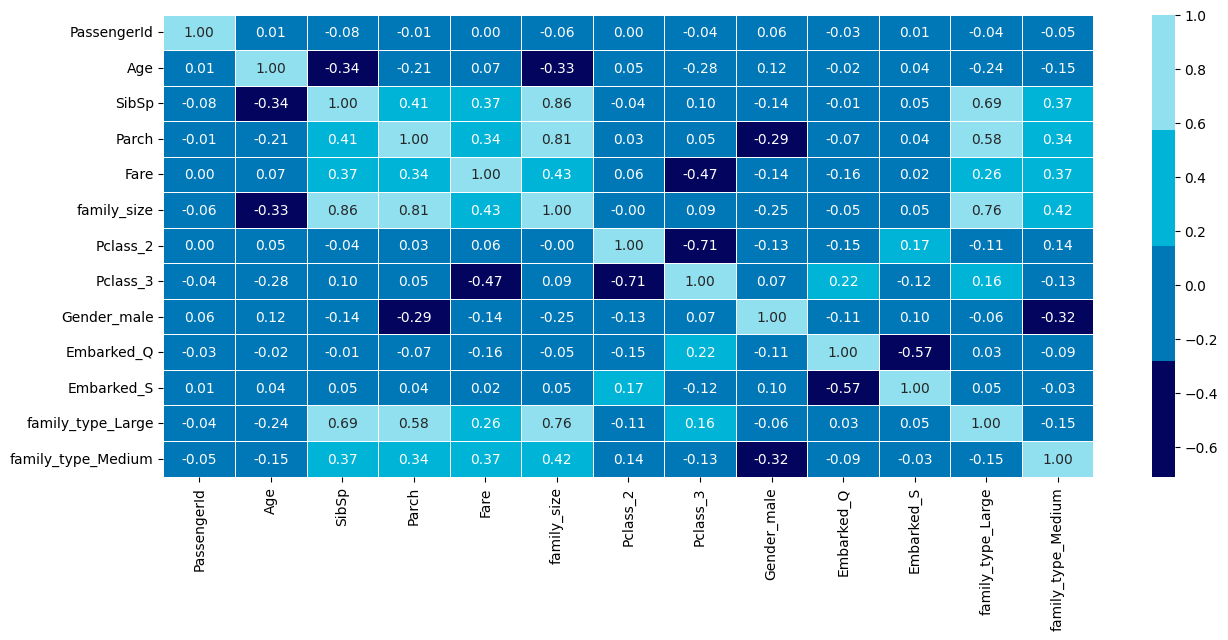

In [48]:
plt.figure(figsize=(15, 6))
sns.heatmap(df.corr(numeric_only=True), 
            cmap=['#03045E', '#0077B6', '#00B4D8', '#90E0EF'],
            annot=True, fmt='.2f', linewidths=0.5)


**Conclusions**
* Chance of female survival is higher than male survival
* Travelling in Pclass 3 was deadliest
* Somehow, people going to C survived more
* People in the age range of 20 to 40 had a higher chance of not surviving
* People travelling with smaller familes had a higher chance of surviving
* the accident in comparison to people with large families and travelling alone